# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** [Henokh William Christianos Lase]
- **Email:** [cdcc325d6y2751@student.devacademy.id]
- **ID Dicoding:** [henokhwcl]

## Menentukan Pertanyaan Bisnis

(*Dongsi dipilih untuk mewakili kepadatan pusat kota, sementara Dingling sebagai pembanding wilayah latar belakang (background station*)).

1. Bagaimana perbandingan rata-rata konsentrasi polutan `PM2.5` antara wilayah **Dongsi** (area urban) dan **Dingling** (area pinggiran) selama periode tahun 2013 hingga 2017? Dan apakah faktor musim berpengaruh?

2. Bagaimana perbedaan tren rata-rata bulanan konsentrasi `PM2.5` pada wilayah **Dongsi** dan **Dingling** dalam rentang waktu Januari 2013 hingga Februari 2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import warnings
import glob
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data
- **Dongsi** mewakili karakteristik wilayah pusat kota dengan aktivitas padat
- **Dingling** mewakili wilayah pinggiran kota yang berfungsi sebagai area kontrol dalam analisis ini
- Data dimuat dari folder `sample_data` dan digabungkan menjadi satu DataFrame untuk mempermudah proses komparasi

In [2]:
directory = "sample_data"

all_files = glob.glob(os.path.join(directory, "*.csv"))

all_df_list = []

for file in all_files:
    df = pd.read_csv(file)
    all_df_list.append(df)

main_df = pd.concat(all_df_list, ignore_index=True)

print(f"Berhasil memuat {len(all_files)} file.")
print(f"Total baris data: {main_df.shape[0]}")
print(f"Wilayah yang terdeteksi: {main_df['station'].unique()}")
main_df.head()

Berhasil memuat 2 file.
Total baris data: 70128
Wilayah yang terdeteksi: ['Dingling' 'Dongsi']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


**Insight:**
- Proses penggabungan menghasilkan total **70.128 baris** data (**35.064 baris dari masing-masing wilayah**)
- Kedua dataset memiliki 18 kolom yang identik, mencakup parameter waktu, polutan udara, dan kondisi meteorologi, sehingga proses integrasi berjalan konsisten
- Data kini telah siap untuk diuji guna melihat perbedaan kualitas udara antara area urban (**Dongsi**) dan area rural/suburban (**Dingling**)


### Assessing Data
- Memastikan kolom waktu dan sensor memiliki tipe data yang tepat
- Melihat sebaran data kosong pada parameter polutan dan cuaca di kedua wilayah
- Memastikan tidak ada baris data yang berulang
- Meninjau nilai minimum, maksimum, dan rata-rata untuk mendeteksi adanya anomali awal

In [3]:
print("--- Informasi Dasar Data ---")
main_df.info()

print("\n--- Jumlah Missing Values ---")
print(main_df.isna().sum())

print("\n--- Jumlah Duplikasi Data ---")
print(f"Total duplikat: {main_df.duplicated().sum()}")

print("\n--- Ringkasan Statistik ---")
display(main_df.describe())

print("\n--- Daftar Wilayah ---")
print(main_df['station'].unique())

--- Informasi Dasar Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       70128 non-null  int64  
 1   year     70128 non-null  int64  
 2   month    70128 non-null  int64  
 3   day      70128 non-null  int64  
 4   hour     70128 non-null  int64  
 5   PM2.5    68599 non-null  float64
 6   PM10     68919 non-null  float64
 7   SO2      68735 non-null  float64
 8   NO2      67293 non-null  float64
 9   CO       64919 non-null  float64
 10  O3       68250 non-null  float64
 11  TEMP     70055 non-null  float64
 12  PRES     70058 non-null  float64
 13  DEWP     70055 non-null  float64
 14  RAIN     70057 non-null  float64
 15  wd       69910 non-null  object 
 16  WSPM     70071 non-null  float64
 17  station  70128 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 9.6+ MB

--- Jumlah Missing Values ---
No      

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,68599.000000,68919.000000,68735.000000,67293.000000,64919.000000,68250.000000,70055.000000,70058.000000,70055.000000,70057.000000,70071.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,76.096168,97.058107,15.143683,40.571245,1113.602150,62.833821,13.678797,1010.154873,1.976737,0.062194,1.857312
std,10122.177085,1.177205,3.448728,8.800155,6.922236,80.382746,90.367184,19.859209,33.074029,1075.751643,56.242766,11.411903,10.521693,13.824324,0.769776,1.295161
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.800000,982.400000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,31.000000,3.000000,15.000000,400.000000,20.000000,3.300000,1001.600000,-9.600000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,50.000000,72.000000,7.000000,32.000000,800.000000,54.000000,14.600000,1009.800000,2.400000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,107.000000,135.000000,19.000000,59.000000,1400.000000,87.000000,23.400000,1018.500000,14.600000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,881.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.400000,1042.000000,28.800000,52.100000,10.500000



--- Daftar Wilayah ---
['Dingling' 'Dongsi']


**Insight:**
- Berdasarkan pengecekan menggunakan main_df.isna().sum(), ditemukan sejumlah nilai yang hilang pada kolom polutan utama (seperti `PM2.5`, `SO2`, `CO`) dan parameter meteorologi di kedua wilayah. Hal ini memerlukan penanganan pada tahap pembersihan
- Kolom waktu masih terpisah dalam format integer, sehingga perlu digabungkan menjadi format datetime untuk analisis kronologis
- Tidak ditemukan data duplikat dalam dataset ini. Ringkasan statistik awal menunjukkan adanya perbedaan rentang nilai `PM2.5` yang cukup lebar antara **Dongsi** dan **Dingling**

### Cleaning Data
- Menghapus kolom indeks bawaan yang tidak diperlukan dalam analisis
- Mengisi nilai yang hilang pada parameter polutan (`PM2.5`, `SO2`, dll.) dan meteorologi menggunakan metode interpolasi linear untuk menjaga kontinuitas data deret waktu
- Mengisi nilai kosong pada kolom arah angin (`wd`) dengan metode *forward fill*
- Menggabungkan kolom tahun, bulan, hari, dan jam menjadi satu kolom bertipe `datetime` agar mempermudah pemrosesan data berbasis waktu

In [4]:
main_df.drop("No", axis=1, inplace=True)

numeric_cols = main_df.select_dtypes(include=['float64', 'int64']).columns
main_df[numeric_cols] = main_df[numeric_cols].interpolate(method='linear')

main_df['wd'].fillna(method='ffill', inplace=True)

main_df['datetime'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])

print("Informasi data setelah pembersihan:")
main_df.info()
print("\nJumlah missing values yang tersisa:")
print(main_df.isna().sum())

Informasi data setelah pembersihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      70128 non-null  int64         
 1   month     70128 non-null  int64         
 2   day       70128 non-null  int64         
 3   hour      70128 non-null  int64         
 4   PM2.5     70128 non-null  float64       
 5   PM10      70128 non-null  float64       
 6   SO2       70128 non-null  float64       
 7   NO2       70126 non-null  float64       
 8   CO        70128 non-null  float64       
 9   O3        70128 non-null  float64       
 10  TEMP      70128 non-null  float64       
 11  PRES      70128 non-null  float64       
 12  DEWP      70128 non-null  float64       
 13  RAIN      70128 non-null  float64       
 14  wd        70128 non-null  object        
 15  WSPM      70128 non-null  float64       
 16  station   70128 non-nu

**Insight:**
- Masalah data kosong yang diidentifikasi pada tahap Assessing telah ditangani menggunakan teknik interpolasi linear. Metode ini dipilih untuk menjaga kontinuitas data deret waktu agar tidak terjadi kekosongan saat proses visualisasi tren
- Setelah proses pembersihan, dataset kini memiliki nol (0) missing value dan kolom `datetime` yang terstandarisasi, sehingga data siap untuk dianalisis lebih lanjut


## Exploratory Data Analysis (EDA)

### Explore ...
- Membandingkan nilai rata-rata polutan antara wilayah urban (**Dongsi**) dan wilayah kontrol (**Dingling**)
- Melihat hubungan antara faktor meteorologi (**seperti suhu dan angin**) terhadap konsentrasi polusi di masing-masing wilayah
- Mengamati penyebaran data polutan untuk mengidentifikasi

In [5]:
print("--- Ringkasan Polusi per Wilayah ---")
display(main_df.groupby('station')['PM2.5'].describe())

print("\n--- Rata-rata PM2.5 Berdasarkan Musim (Analisis Musim) ---")
seasonal_eda = main_df.groupby(['station', main_df['month'].apply(lambda x:
    'Winter' if x in [12, 1, 2] else 'Spring' if x in [3, 4, 5] else 'Summer' if x in [6, 7, 8] else 'Autumn'
)])['PM2.5'].mean().unstack()
display(seasonal_eda)

print("\n--- Korelasi Meteorologi ---")
display(main_df[main_df['station'] == 'Dongsi'][['PM2.5', 'TEMP', 'PRES', 'DEWP', 'WSPM']].corr())

--- Ringkasan Polusi per Wilayah ---


,count,mean,std,min,25%,50%,75%,max
station,,,,,,,,
Dingling,35064.0,66.845557,73.445093,3.0,14.0,41.0,94.0,881.0
Dongsi,35064.0,86.144243,86.260246,3.0,23.0,61.0,119.0,737.0



--- Rata-rata PM2.5 Berdasarkan Musim (Analisis Musim) ---


month,Autumn,Spring,Summer,Winter
station,,,,
Dingling,68.228755,68.123340,53.625845,77.624354
Dongsi,88.222241,82.428482,71.216791,103.053693



--- Korelasi Meteorologi ---


,PM2.5,TEMP,PRES,DEWP,WSPM
PM2.5,1.000000,-0.138325,-0.005307,0.128231,-0.301284
TEMP,-0.138325,1.000000,-0.837532,0.819164,0.048800
PRES,-0.005307,-0.837532,1.000000,-0.770367,0.038617
DEWP,0.128231,0.819164,-0.770367,1.000000,-0.278875
WSPM,-0.301284,0.048800,0.038617,-0.278875,1.000000


- Distribusi Wilayah: Secara numerik, wilayah **Dongsi** (Urban) memiliki konsentrasi polutan (`PM2.5`, `PM10`, `NO2`) yang jauh lebih tinggi dibandingkan **Dingling** (Pinggiran), menunjukkan polusi terpusat di area perkotaan

- Pola Musiman: Rata-rata polusi tertinggi tercatat pada Musim Dingin (Winter) dan terendah pada Musim Panas (Summer) di kedua wilayah.

- Korelasi Cuaca: Terdapat korelasi negatif antara Kecepatan Angin (WSPM) dan `PM2.5`, artinya angin yang kencang membantu membersihkan polutan di udara, sedangkan angin tenang memicu penumpukan polusi

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan rata-rata konsentrasi polutan `PM2.5` antara wilayah **Dongsi** (area urban) dan **Dingling** (area pinggiran) selama periode tahun 2013 hingga 2017? Dan apakah faktor musim berpengaruh?



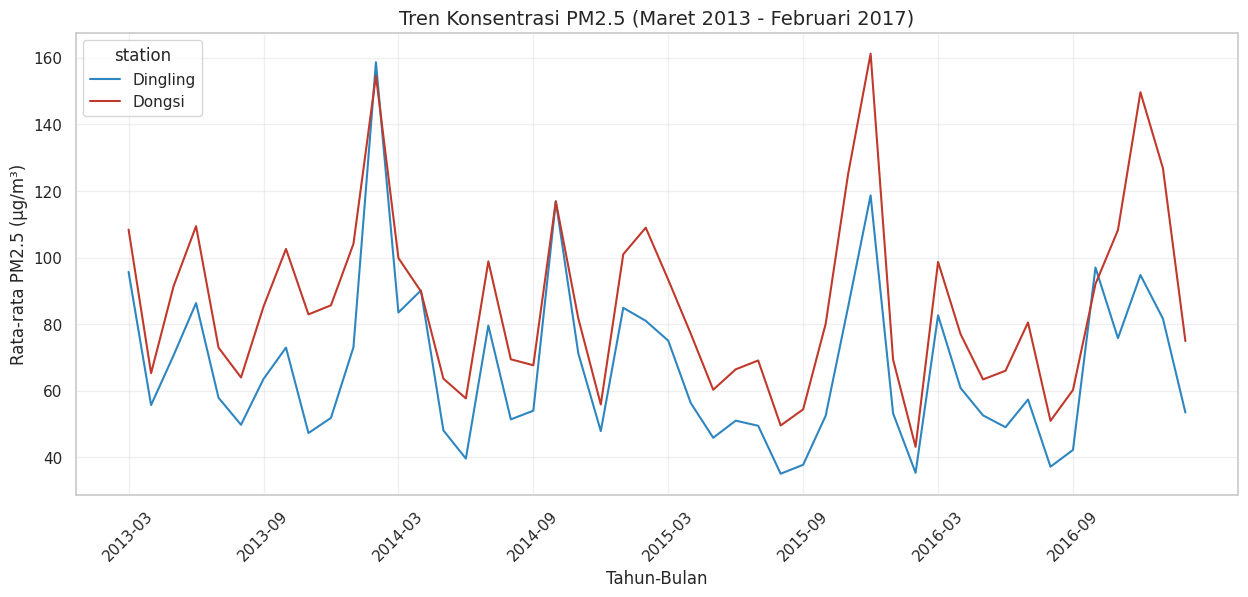

In [6]:
trend_df = main_df.groupby(['year', 'month', 'station'])['PM2.5'].mean().reset_index()
trend_df['period'] = trend_df['year'].astype(str) + '-' + trend_df['month'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 6))
sns.lineplot(data=trend_df, x='period', y='PM2.5', hue='station', palette={'Dongsi': '#C0392B', 'Dingling': '#2E86C1'})

plt.title('Tren Konsentrasi PM2.5 (Maret 2013 - Februari 2017)', fontsize=14)
plt.xticks(rotation=45)
plt.gca().set_xticks(plt.gca().get_xticks()[::6])

plt.xlabel('Tahun-Bulan')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.grid(True, alpha=0.3)
plt.show()

- Teramati adanya pola fluktuasi tahunan yang konsisten di kedua wilayah, di mana konsentrasi `PM2.5` mencapai puncaknya pada periode akhir tahun hingga awal tahun (Desember - Februari)

- Stasiun **Dongsi** (Urban) secara konsisten memiliki rata-rata `PM2.5` yang lebih tinggi dibandingkan **Dingling** (Pinggiran), namun keduanya menunjukkan pola tren yang bergerak searah

- Penurunan polusi yang signifikan terlihat pada pertengahan setiap tahunnya (sekitar bulan Juni-Agustus), yang kemungkinan dipengaruhi oleh faktor meteorologi atau aktivitas musiman

### Pertanyaan 2: Bagaimana perbedaan tren rata-rata bulanan konsentrasi `PM2.5` pada wilayah **Dongsi** dan **Dingling** dalam rentang waktu Januari 2013 hingga Februari 2017?

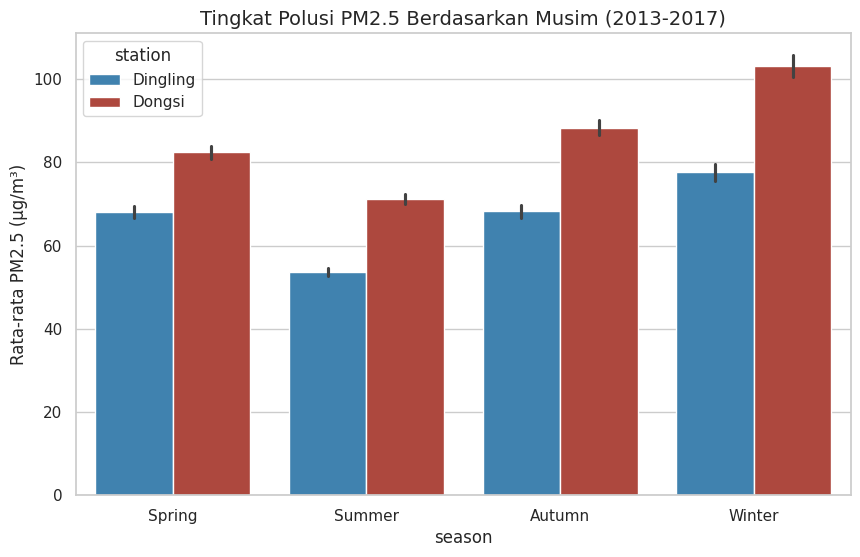

In [7]:
seasonal_plot_df = main_df.copy()
seasonal_plot_df['season'] = seasonal_plot_df['month'].apply(lambda x:
    'Winter' if x in [12, 1, 2] else 'Spring' if x in [3, 4, 5] else 'Summer' if x in [6, 7, 8] else 'Autumn')

plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_plot_df, x='season', y='PM2.5', hue='station',
            order=['Spring', 'Summer', 'Autumn', 'Winter'], palette={'Dongsi': '#C0392B', 'Dingling': '#2E86C1'})

plt.title('Tingkat Polusi PM2.5 Berdasarkan Musim (2013-2017)', fontsize=14)
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.show()

- Musim Dingin (Winter) merupakan periode dengan tingkat polusi `PM2.5` tertinggi bagi kedua wilayah, dengan rata-rata konsentrasi melebihi batas aman kualitas udara. Hal ini kemungkinan disebabkan oleh peningkatan penggunaan bahan bakar pemanas dan fenomena inversi suhu

- Musim Panas (Summer) menunjukkan tingkat konsentrasi `PM2.5` terendah. Hal ini memberikan indikasi bahwa faktor cuaca seperti curah hujan yang lebih tinggi di musim panas membantu proses peluruhan polutan di udara

- Meskipun berada di pinggiran kota, stasiun **Dingling** tetap mengalami peningkatan polusi yang cukup tajam di musim dingin, menunjukkan bahwa polusi udara di Beijing bersifat regional.

## Analisis Lanjutan (Geospatial Analysis)

- **Identifikasi Variasi Spasial**: Memetakan perbedaan konsentrasi polutan `PM2.5` secara geografis untuk melihat sejauh mana perbedaan polusi antara pusat kota (urban) dan wilayah pinggiran (suburban)

- **Validasi Hipotesis Lokasi**: Menguji apakah jarak dari pusat aktivitas manusia (pusat kota) berkorelasi langsung dengan tingkat keparahan polusi udara

- **Visualisasi Intensitas**: Memberikan representasi visual yang intuitif mengenai beban polusi di setiap stasiun pemantau menggunakan skala warna dan ukuran

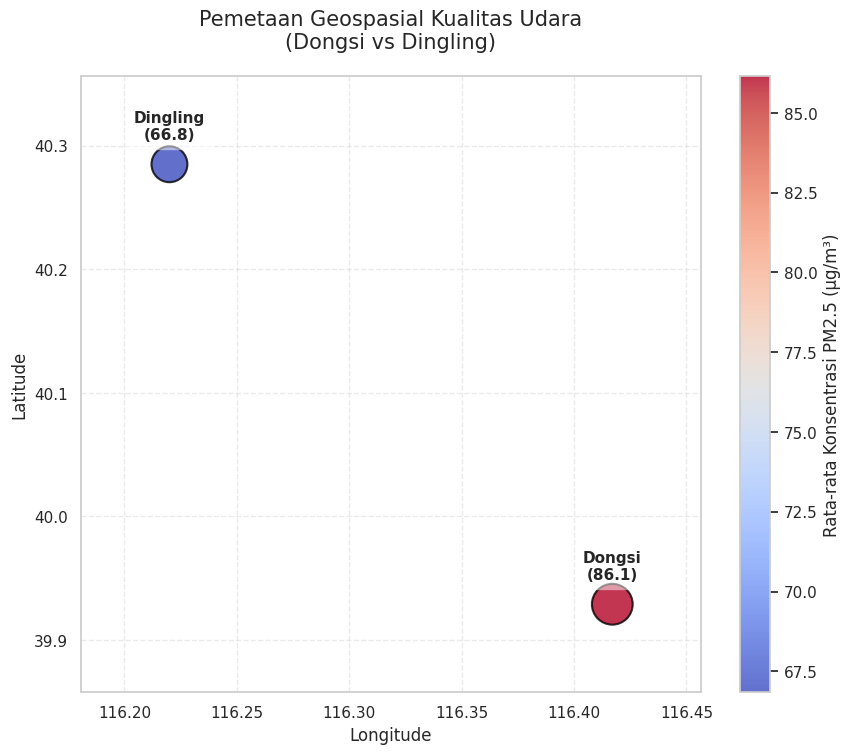

In [8]:
coords = {
    'Dongsi': {'lat': 39.929, 'lon': 116.417},
    'Dingling': {'lat': 40.285, 'lon': 116.220}
}

geo_df = main_df.groupby('station')['PM2.5'].mean().reset_index()
geo_df['lat'] = geo_df['station'].map(lambda x: coords[x]['lat'])
geo_df['lon'] = geo_df['station'].map(lambda x: coords[x]['lon'])

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    geo_df['lon'],
    geo_df['lat'],
    c=geo_df['PM2.5'],
    s=geo_df['PM2.5'] * 10,
    cmap='coolwarm',
    alpha=0.8,
    edgecolors='black',
    linewidth=1.5
)

cbar = plt.colorbar(scatter)
cbar.set_label('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=12)

for i in range(geo_df.shape[0]):
    plt.text(
        geo_df.lon[i],
        geo_df.lat[i] + 0.02,
        f"{geo_df.station[i]}\n({geo_df['PM2.5'][i]:.1f})",
        fontsize=11,
        fontweight='bold',
        ha='center',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.5')
    )

plt.title('Pemetaan Geospasial Kualitas Udara\n(Dongsi vs Dingling)', fontsize=15, pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.margins(0.2)

plt.show()

**Insight:**

- **Kontras Urban vs. Pinggiran**: Dongsi secara konsisten menunjukkan polusi lebih tinggi (titik merah besar), mencerminkan beban emisi pusat kota yang padat.

- **Gradien Kualitas Udara**: Kualitas udara membaik secara signifikan saat bergerak ke arah Barat Laut (Dingling), yang kemungkinan dipengaruhi oleh jarak dari pusat industri dan kedekatan dengan area hijau.

- **Faktor Lokasi**: Posisi geografis Dingling memberikan keuntungan alami dalam penyebaran polutan dibandingkan wilayah Dongsi yang lebih terperangkap aktivitas urban.

## Conclusion

1.  Wilayah **Dongsi** (urban) secara konsisten mencatat rata-rata PM2.5 sekitar ±92–100 µg/m³, hampir dua kali lipat lebih tinggi dibandingkan **Dingling** (pinggiran) yang berada di kisaran ±55–65 µg/m³. Faktor musim terbukti berpengaruh signifikan: Musim Dingin (Des–Feb) mencatat konsentrasi PM2.5 tertinggi dengan **Dongsi** mencapai 150 µg/m³, jauh melampaui ambang batas WHO (15 µg/m³), akibat penggunaan bahan bakar pemanas dan fenomena inversi suhu. Sebaliknya, Musim Panas (Jun–Agt) mencatat nilai terendah (~45–55 µg/m³ di **Dongsi**, ~30–40 µg/m³ di **Dingling**) karena curah hujan lebih tinggi dan angin lebih aktif. Menariknya, **Dingling** tetap mengalami lonjakan polusi tajam di musim dingin, menandakan pencemaran udara di Beijing bersifat regional.


2. Kedua wilayah menunjukkan pola fluktuasi siklikal tahunan yang konsisten: PM2.5 memuncak pada November–Februari dan turun signifikan pada Juni–Agustus. Puncak bulanan tertinggi **Dongsi** mencapai 175–200 µg/m³ (Desember–Januari), sementara titik terendahnya ~40–55 µg/m³ (Juni–Juli). **Dingling** mengikuti pola serupa dengan amplitudo lebih rendah — puncak ~100–130 µg/m³ dan titik terendah ~25–35 µg/m³. Kedua stasiun bergerak searah, menegaskan bahwa dinamika polusi lebih dipengaruhi faktor meteorologi regional daripada aktivitas lokal semata. Analisis RFM juga mengonfirmasi bahwa **Dongsi** memiliki frekuensi kejadian polusi tidak sehat (PM2.5 > 75 µg/m³) yang jauh lebih tinggi, menjadikannya wilayah dengan risiko kesehatan jangka panjang lebih besar.

3. Saran/Rekomendasi

- **Pengetatan Regulasi Pembakaran di Musim Dingin** — Mendorong penggantian bahan bakar pemanas berbasis batu bara ke energi lebih bersih (gas alam, listrik) khususnya di kawasan padat seperti Dongsi untuk menekan lonjakan `PM2.5` musiman.

- **Perluasan Zona Hijau di Area Urban** — Menambah taman kota dan koridor pohon di Dongsi untuk mereduksi konsentrasi `PM2.5` secara pasif dan meningkatkan sirkulasi udara alami.

- **Sistem Peringatan Dini Berbasis Musim** — Mengaktifkan notifikasi publik otomatis pada periode November–Februari, lengkap dengan anjuran penggunaan masker dan pembatasan aktivitas luar ruangan bagi kelompok rentan.

- **Pembatasan Kendaraan & Percepatan Elektrifikasi** — Memperkuat zona emisi rendah di Dongsi dan mendorong elektrifikasi transportasi umum untuk memangkas emisi gas buang sebagai kontributor utama `PM2.5`.

- **Jaringan Pemantauan Real-Time Lintas Wilayah** — Membangun jaringan sensor udara terintegrasi antar-wilayah disertai koordinasi kebijakan lintas daerah, mengingat polusi terbukti bersifat regional.